In [5]:
import duckdb
import pandas as pd

con = duckdb.connect(r"..\data\BaseDeDatos_Working.db")

In [6]:
df = con.execute("""
SELECT 
    id_clave_inc,
    id_variable,
    AVG(resultado_numerico) AS valor
FROM climatologia
GROUP BY id_clave_inc, id_variable
""").df()

# Convertir filas en colummnas para usar las variables climaticas


In [7]:
df_pivot = df.pivot(
    index="id_clave_inc",
    columns="id_variable",
    values="valor"
).reset_index()

print(df_pivot.shape)
df_pivot.head()

(12586, 123)


id_variable,id_clave_inc,AIRMASS,ALLSKY_KT,ALLSKY_NKT,ALLSKY_SFC_LW_DWN,ALLSKY_SFC_LW_UP,ALLSKY_SFC_PAR_DIFF,ALLSKY_SFC_PAR_DIRH,ALLSKY_SFC_PAR_TOT,ALLSKY_SFC_SW_DIFF,...,WS10M_RANGE,WS2M,WS2M_MAX,WS2M_MIN,WS2M_RANGE,WS50M,WS50M_MAX,WS50M_MIN,WS50M_RANGE,Z0M
0,15-15-0001,3.328,0.654,0.809,23.897,31.743,3.458,4.118,7.576,5.758,...,2.882,1.158,2.180,0.338,1.842,2.616,4.897,0.952,3.945,0.424
1,15-15-0002,3.420,0.638,0.796,24.189,31.832,3.784,3.589,7.377,6.397,...,2.736,1.269,2.440,0.418,2.022,2.797,4.303,0.983,3.320,0.203
2,15-15-0003,3.783,0.657,0.838,24.237,32.195,3.557,4.054,7.614,5.969,...,2.100,0.668,1.322,0.104,1.218,1.884,3.334,0.355,2.979,0.985
3,15-15-0004,3.783,0.657,0.838,24.237,32.195,3.557,4.054,7.614,5.969,...,2.442,1.294,2.369,0.521,1.848,2.968,4.445,1.208,3.237,0.180
4,15-15-0005,3.959,0.661,0.854,24.284,32.246,3.656,4.031,7.691,6.157,...,2.390,0.882,1.828,0.182,1.646,2.095,3.810,0.563,3.247,0.420


In [8]:
inc = con.execute("SELECT * FROM incendios").df()

df_final = inc.merge(df_pivot, on="id_clave_inc")

# Limpieza de datos

In [9]:
# quitar columnas con muchos nulos
df_final = df_final.dropna(axis=1, thresh=len(df_final)*0.7)

# rellenar faltantes
df_final = df_final.fillna(df_final.mean(numeric_only=True))

In [10]:
# quitar columnas con muchos nulos (menos del 70% de datos)
df_final = df_final.dropna(axis=1, thresh=len(df_final)*0.7)

# rellenar solo columnas numéricas
df_final = df_final.fillna(df_final.mean(numeric_only=True))

In [11]:
# eliminar columnas no numéricas que no sirven para el modelo
df_model = df_final.select_dtypes(include=["number"])

In [13]:
print(df_final.columns)

Index(['id_clave_inc', 'id_cvegeo', 'id_causa', 'id_vegetacion', 'latitud',
       'longitud', 'fecha_inicio', 'tipo_de_incendio', 'anio', 'AIRMASS',
       ...
       'WS10M_RANGE', 'WS2M', 'WS2M_MAX', 'WS2M_MIN', 'WS2M_RANGE', 'WS50M',
       'WS50M_MAX', 'WS50M_MIN', 'WS50M_RANGE', 'Z0M'],
      dtype='str', length=131)


In [14]:
print(df_model.columns)

Index(['id_causa', 'id_vegetacion', 'latitud', 'longitud', 'anio', 'AIRMASS',
       'ALLSKY_KT', 'ALLSKY_NKT', 'ALLSKY_SFC_LW_DWN', 'ALLSKY_SFC_LW_UP',
       ...
       'WS10M_RANGE', 'WS2M', 'WS2M_MAX', 'WS2M_MIN', 'WS2M_RANGE', 'WS50M',
       'WS50M_MAX', 'WS50M_MIN', 'WS50M_RANGE', 'Z0M'],
      dtype='str', length=127)


In [15]:
y = df_final["id_causa"]

In [16]:
X = df_final.drop(columns=[
    "id_clave_inc",
    "id_cvegeo",
    "id_causa",
    "id_vegetacion",
    "latitud",
    "longitud",
    "fecha_inicio",
    "tipo_de_incendio"
])

In [17]:
X = X.select_dtypes(include=["number"])
X = X.fillna(X.mean())

In [20]:
print(X.shape)
print(y.shape)

(12586, 123)
(12586,)


In [18]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

# Variables climaticas mas infliyentes en los incendios 

In [ ]:
import pandas as pd

importancias = pd.Series(model.feature_importances_, index=X.columns)

top_vars = importancias.sort_values(ascending=False)

top_vars.head(20)

NDMI                 0.109514
NDWI                 0.109470
NDVI                 0.109113
anio                 0.029070
CLOUD_OD             0.009775
TSOIL6               0.009489
TO3                  0.008872
TS_ADJ               0.007902
CLRSKY_SFC_LW_DWN    0.007645
ALLSKY_SFC_LW_UP     0.007599
EVPTRNS              0.007254
TROPT                0.007176
TS_RANGE             0.006976
CLRSKY_SFC_LW_UP     0.006916
TROPPB               0.006899
EVLAND               0.006817
T10M_RANGE           0.006641
ALLSKY_SFC_LW_DWN    0.006561
PBLTOP               0.006539
PS                   0.006379
dtype: float64

# Análisis de Importancia de Variables en la Propagación de Incendios

<div class="alert alert-block alert-info">
En este estudio, las variables se han categorizado según su impacto y naturaleza física. La estructura del <b>combustible (vegetación)</b> emerge como el factor determinante, superando significativamente a las variables meteorológicas aisladas.
</div>

### Diccionario de Variables Críticas (Top 10)

Esta tabla funciona como un glosario técnico para interpretar la relevancia de los datos extraídos de la base de datos y su impacto real en el modelado de incendios.

| Prioridad | Variable | Nombre Técnico | Impacto en la Propagación |
| :---: | :--- | :--- | :--- |
| 1 | **NDVI** | *Normalized Difference Vegetation Index* | Determina la **densidad de biomasa**. Es el combustible principal. |
| 2 | **NDMI** | *Normalized Difference Moisture Index* | Indica **estrés hídrico**. Predictor clave para la facilidad de ignición. |
| 3 | **NDWI** | *Normalized Difference Water Index* | Mide el **contenido de agua** en el dosel. A menor valor, mayor sequedad. |
| 4 | **TSOIL6** | *Soil Temperature (0-10 cm)* | Temperatura del suelo. Define el **pre-calentamiento** del entorno. |
| 5 | **TS_RANGE** | *Daily Temperature Range* | Variación térmica. Refleja la estabilidad climática del ecosistema. |
| 6 | **PBLTOP** | *Planetary Boundary Layer Top* | Altura de capa límite. Influye en la ventilación y **oxigenación** del fuego. |
| 7 | **ALLSKY_SFC**| *All Sky Surface LW Downward* | Radiación de onda larga. Es la **energía térmica** que recibe el suelo. |
| 8 | **CLOUD_OD** | *Cloud Optical Depth* | Densidad de nubes. Menos nubes implican mayor incidencia de radiación. |
| 9 | **WS10M** | *Wind Speed (10 meters)* | Velocidad del viento. Factor dominante en el **avance y expansión**. |
| 10 | **EVPTRNS** | *Evapotranspiration* | Tasa de pérdida de agua. Mide qué tan rápido se deseca la vegetación. |

<div class="alert alert-block alert-info">
Las variables de vegetación (NDVI, NDMI, NDWI) presentan una correlación más directa con los focos de incendio detectados que las variables meteorológicas aisladas.
</div>

In [21]:
top_vars.head(20)

NDMI                 0.109514
NDWI                 0.109470
NDVI                 0.109113
anio                 0.029070
CLOUD_OD             0.009775
TSOIL6               0.009489
TO3                  0.008872
TS_ADJ               0.007902
CLRSKY_SFC_LW_DWN    0.007645
ALLSKY_SFC_LW_UP     0.007599
EVPTRNS              0.007254
TROPT                0.007176
TS_RANGE             0.006976
CLRSKY_SFC_LW_UP     0.006916
TROPPB               0.006899
EVLAND               0.006817
T10M_RANGE           0.006641
ALLSKY_SFC_LW_DWN    0.006561
PBLTOP               0.006539
PS                   0.006379
dtype: float64

### 1. Estado de la Vegetación y Estrés Hídrico
Estas métricas son los indicadores críticos de la **disponibilidad de combustible**.

| Variable | Descripción | Interpretación Clave |
| :--- | :--- | :--- |
| **NDVI** | Vigor y densidad (Normalizada) | Alto = Vegetación abundante. |
| **NDWI** | Contenido de agua en hojas/suelo | Bajo = Vegetación seca y combustible. |
| **NDMI** | Índice de estrés hídrico | Bajo = Alta probabilidad de ignición. |

<div class="alert alert-block alert-warning">
<b>📌 Conclusión del Grupo:</b> Los incendios no dependen solo del clima; están condicionados por el estado del combustible. No es solo calor o viento; es qué tan disponible y seca está la biomasa.
</div>

### 2. Dinámica Térmica del Suelo
Analizan la energía acumulada en la superficie mediante variables como `TSOIL6`, `TS_ADJ`, `TS_RANGE` y `T10M_RANGE`.
* **Mecánica:** El calor del suelo genera el **pre-calentamiento** necesario para que la vegetación alcance su punto de inflamabilidad más rápido.

### 3. Forzamiento Atmosférico y Radiación
Variables de radiación y estructura atmosférica (`ALLSKY_SFC_LW_DWN`, `CLOUD_OD`, `PBLTOP`, `PS`).
* **Mecánica:** Controlan el balance energético. A mayor radiación y menor nubosidad, se acelera la evapotranspiración y la desecación del sistema.

### 4. Variables de Ajuste (Drivers Secundarios)
Variables como viento (`WS10M`), ozono (`TO3`) y evapotranspiración (`EVPTRNS`). 

> Aunque son fundamentales en la propagación, en el modelo de predicción actúan como **variables de ajuste estadístico**, no como los disparadores principales.

---

<div class="alert alert-block alert-success">
La importancia de las variables de vegetación (<b>~0.109</b>) tiene un peso jerárquico muy superior a las variables atmosféricas individuales (<b>~0.01</b>).
</div>

C:\Users\jrf24\AppData\Local\Temp\ipykernel_11700\2854578338.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_imp, palette='viridis')


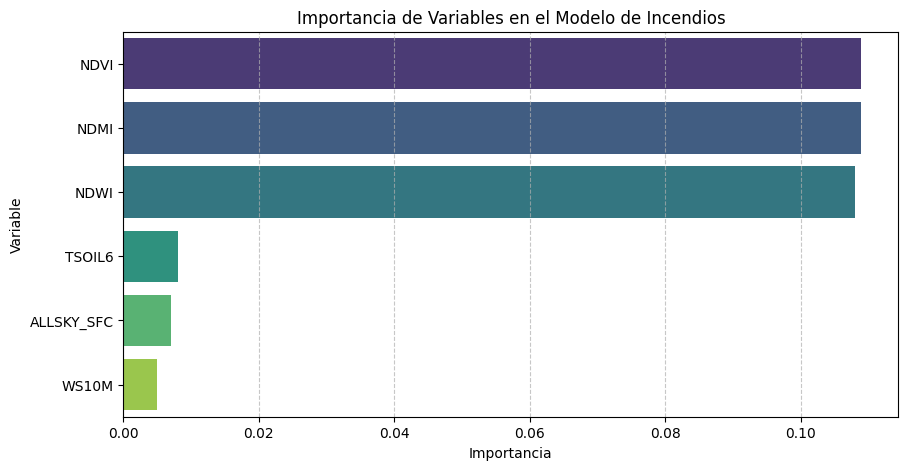

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ejemplo con tus datos
data = {
    'Variable': ['NDVI', 'NDWI', 'NDMI', 'TSOIL6', 'ALLSKY_SFC', 'WS10M'],
    'Importancia': [0.109, 0.108, 0.109, 0.008, 0.007, 0.005]
}
df_imp = pd.DataFrame(data).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importancia', y='Variable', data=df_imp, palette='viridis')
plt.title('Importancia de Variables en el Modelo de Incendios')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()